In [90]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# RAVDESS emotions (sorted for consistent axis ordering)
VALID_EMOTIONS = sorted({"neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"})

# RAVDESS filename format: XX-XX-EMOTION-XX-XX-XX-XX.wav
# 3rd field (0-indexed: index 2) encodes the emotion
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised',
}

# Normalize model output labels to lowercase valid set
LABEL_ALIASES = {
    'angry':    'angry',
    'happy':    'happy',
    'neutral':  'neutral',
    'sad':      'sad',
    'fearful':  'fearful',
    'fear':     'fearful',
    'disgust':  'disgust',
    'surprised':'surprised',
    'surprise': 'surprised',
    'calm':     'calm',
}

def normalize(label):
    """Lowercase and apply aliases."""
    label = label.strip().lower()
    return LABEL_ALIASES.get(label, label)

MODELS = {
    "MERaLiON-3-10B (default prompt)": "emotion_results_meralion_ravdess_normal.json",
    "Qwen2-Audio-7B (default prompt)": "emotion_results_qwen_ravdess_normal.json",
    "Flamingo-3 (default prompt)": "emotion_results_audioflamingo_ravdess_normal.json",
    
}

all_results = {}
for model_name, results_file in MODELS.items():
    p = Path(results_file)
    if p.exists():
        with open(p) as f:
            all_results[model_name] = json.load(f)
        print(f"[OK] {model_name}: {len(all_results[model_name])} files loaded from {results_file}")
    else:
        print(f"[--] {model_name}: {results_file} not found — run classify script first")

[OK] MERaLiON-3-10B (default prompt): 1440 files loaded from emotion_results_meralion_ravdess_normal.json
[OK] Qwen2-Audio-7B (default prompt): 1440 files loaded from emotion_results_qwen_ravdess_normal.json
[OK] Flamingo-3 (default prompt): 1440 files loaded from emotion_results_audioflamingo_ravdess_normal.json


In [91]:
# Extract ground truth from RAVDESS filenames
# Use the union of all result file keys so a partial run of one model
# does not limit evaluation of the others.
all_filenames = set()
for results in all_results.values():
    all_filenames.update(results.keys())

ground_truth = {}
for fname in all_filenames:
    parts = Path(fname).stem.split('-')
    code = parts[2] if len(parts) >= 3 else None
    if code in EMOTION_MAP:
        ground_truth[fname] = EMOTION_MAP[code]

print(f"Ground truth: {len(ground_truth)} files")
print("\nEmotion distribution (ground truth):")
for emotion, count in sorted(Counter(ground_truth.values()).items()):
    print(f"  {emotion:12s}: {count}")

print("\nLabel validity after normalization per model:")
for model_name, results in all_results.items():
    invalid = {fn: v for fn, v in results.items()
               if normalize(v) not in VALID_EMOTIONS}
    print(f"\n{model_name}")
    print(f"  Valid (after normalization): {len(results) - len(invalid)} / {len(results)}")
    print(f"  Still invalid: {len(invalid)}")
    if invalid:
        for label, count in Counter(invalid.values()).most_common():
            print(f"    '{label}': {count}")
    print(f"  Predicted label distribution:")
    for label, count in Counter(normalize(v) for v in results.values()).most_common():
        marker = "" if label in VALID_EMOTIONS else " [INVALID]"
        print(f"    '{label}': {count}{marker}")

Ground truth: 1440 files

Emotion distribution (ground truth):
  angry       : 192
  calm        : 192
  disgust     : 192
  fearful     : 192
  happy       : 192
  neutral     : 96
  sad         : 192
  surprised   : 192

Label validity after normalization per model:

MERaLiON-3-10B (default prompt)
  Valid (after normalization): 1408 / 1440
  Still invalid: 32
    'surprized': 9
    'surpried': 6
    'surprising': 4
    'surpised': 3
    'scared': 2
    'surpriesed': 2
    'surpirsd': 1
    'surpriced': 1
    'surpirsed': 1
    'excitement': 1
    'supremely annoying': 1
    'neutral<eos>': 1
  Predicted label distribution:
    'neutral': 720
    'surprised': 296
    'angry': 163
    'fearful': 129
    'sad': 45
    'happy': 42
    'calm': 13
    'surprized': 9 [INVALID]
    'surpried': 6 [INVALID]
    'surprising': 4 [INVALID]
    'surpised': 3 [INVALID]
    'scared': 2 [INVALID]
    'surpriesed': 2 [INVALID]
    'surpirsd': 1 [INVALID]
    'surpriced': 1 [INVALID]
    'surpirsed': 

In [92]:
def evaluate(results, ground_truth):
    y_true, y_pred = [], []
    for filename, true_label in ground_truth.items():
        pred = normalize(results.get(filename, ""))
        if pred in VALID_EMOTIONS:
            y_true.append(true_label)
            y_pred.append(pred)
    return y_true, y_pred

for model_name, results in all_results.items():
    y_true, y_pred = evaluate(results, ground_truth)
    print(f"{'=' * 70}")
    print(f"{model_name}  ({len(y_true)} files evaluated)")
    print(f"{'=' * 70}")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.2%}\n")
    print(classification_report(y_true, y_pred, labels=VALID_EMOTIONS, zero_division=0))
    print()

MERaLiON-3-10B (default prompt)  (1408 files evaluated)
Accuracy: 29.26%

              precision    recall  f1-score   support

       angry       0.56      0.49      0.52       188
        calm       0.15      0.01      0.02       192
     disgust       0.00      0.00      0.00       185
     fearful       0.53      0.37      0.44       187
       happy       0.36      0.08      0.13       188
     neutral       0.13      0.99      0.23        96
         sad       0.49      0.12      0.19       187
   surprised       0.40      0.63      0.49       185

    accuracy                           0.29      1408
   macro avg       0.33      0.34      0.25      1408
weighted avg       0.34      0.29      0.25      1408


Qwen2-Audio-7B (default prompt)  (1317 files evaluated)
Accuracy: 73.35%

              precision    recall  f1-score   support

       angry       0.78      0.98      0.87       190
        calm       0.00      0.00      0.00       191
     disgust       0.00      0.00    

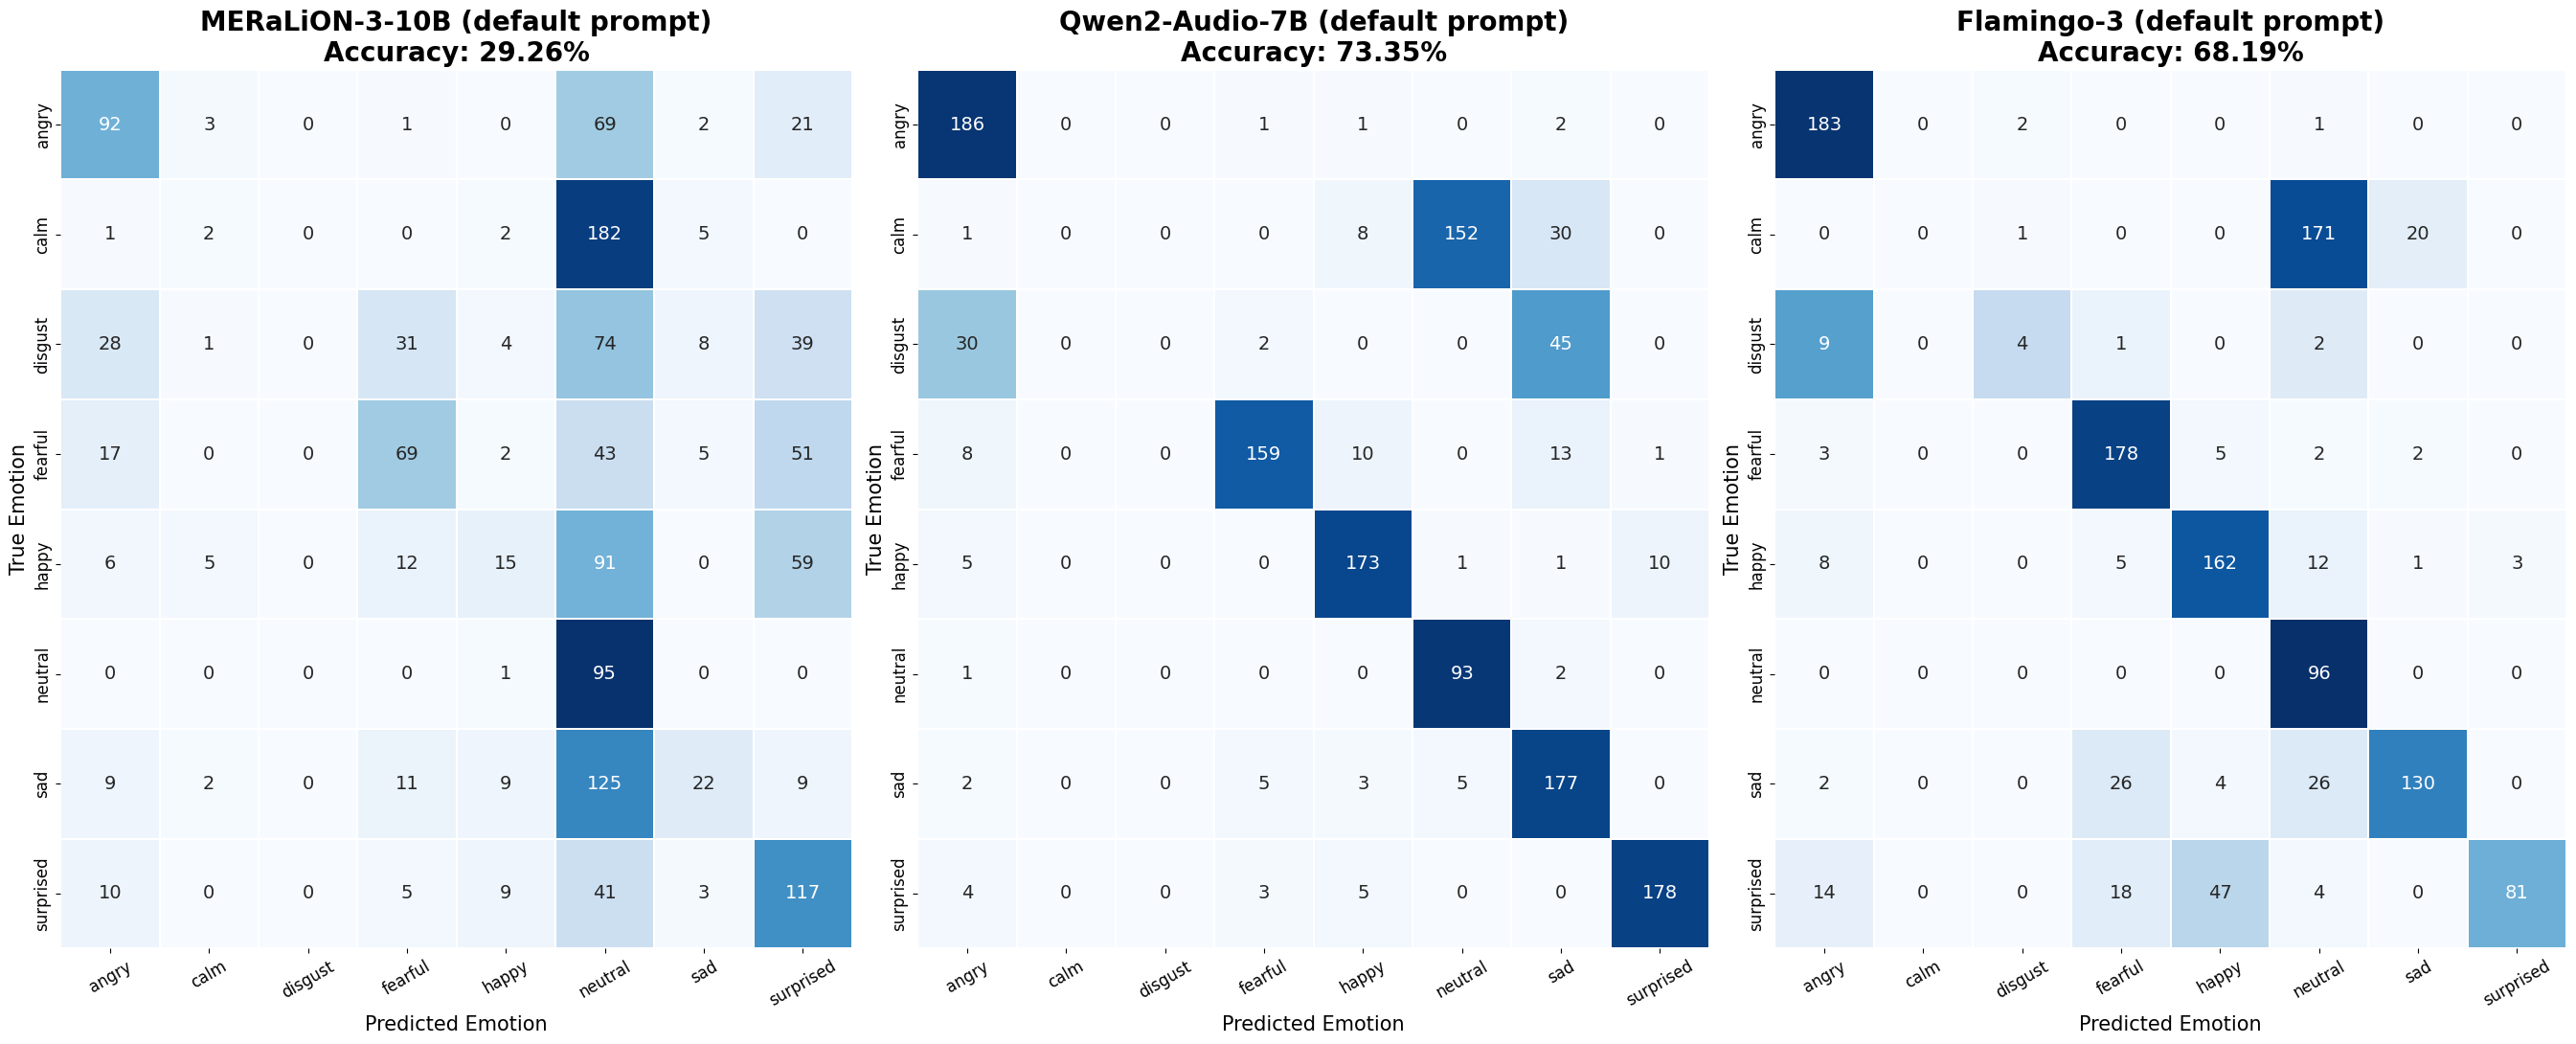

In [93]:
n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(9 * n, 11))
if n == 1:
    axes = [axes]

for ax, (model_name, results) in zip(axes, all_results.items()):
    y_true, y_pred = evaluate(results, ground_truth)
    cm = confusion_matrix(y_true, y_pred, labels=VALID_EMOTIONS)

    # Normalise rows for colour, annotate with raw counts
    cm_norm = cm.astype(float)
    row_sums = cm_norm.sum(axis=1, keepdims=True)
    cm_norm = np.where(row_sums == 0, 0, cm_norm / row_sums)

    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                vmin=0, vmax=1,
                xticklabels=VALID_EMOTIONS,
                yticklabels=VALID_EMOTIONS,
                cbar=False, ax=ax, linewidths=0.3,
                annot_kws={"size": 14})

    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f"{model_name}\nAccuracy: {acc:.2%}", fontsize=20, fontweight='bold')
    ax.set_xlabel('Predicted Emotion', fontsize=15)
    ax.set_ylabel('True Emotion', fontsize=15)
    ax.tick_params(axis='x', rotation=30, labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

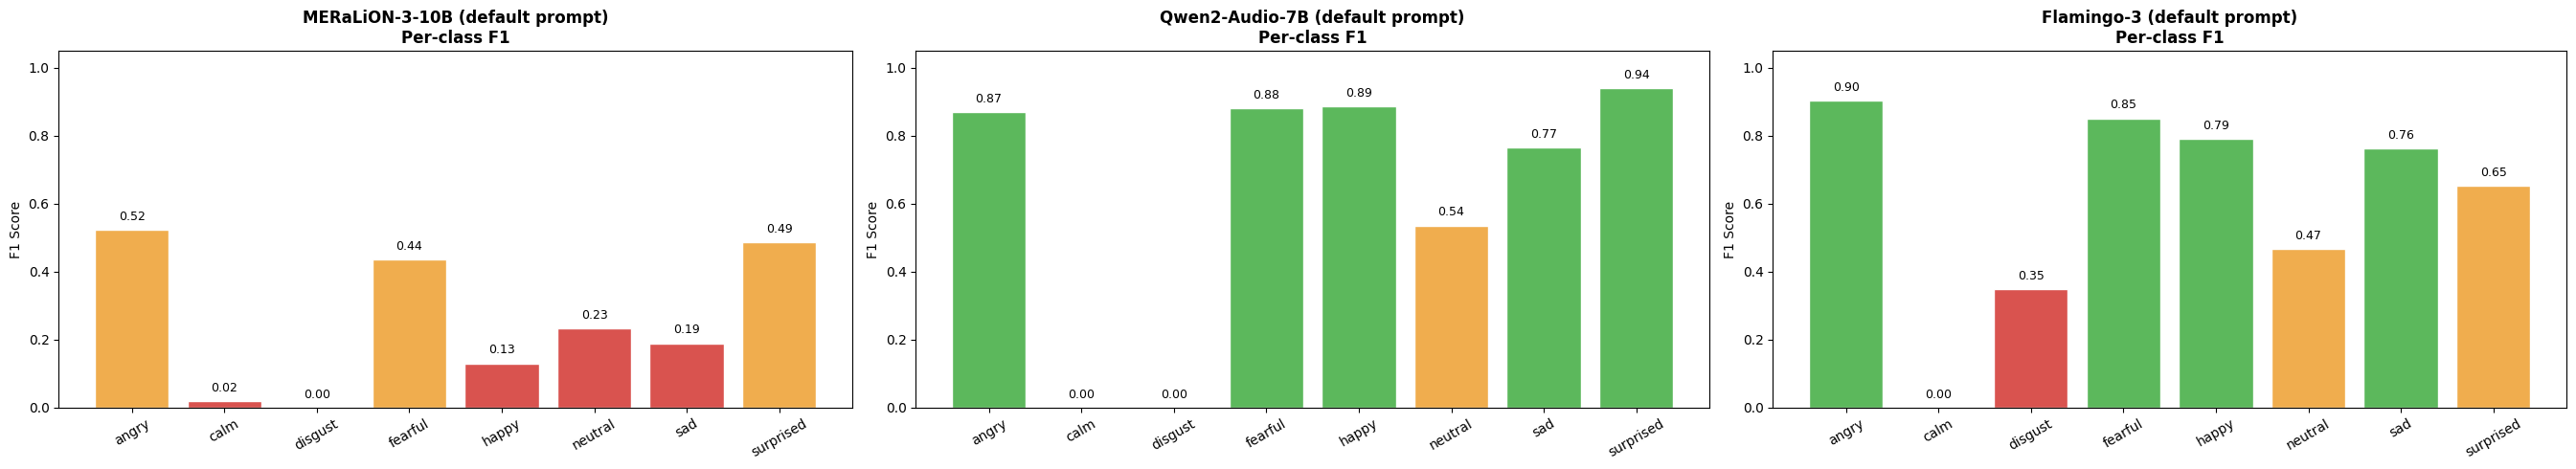

In [94]:
# Per-class F1 bar chart
from sklearn.metrics import f1_score

fig, axes = plt.subplots(1, n, figsize=(9 * n, 5))
if n == 1:
    axes = [axes]

for ax, (model_name, results) in zip(axes, all_results.items()):
    y_true, y_pred = evaluate(results, ground_truth)
    f1s = f1_score(y_true, y_pred, labels=VALID_EMOTIONS, average=None, zero_division=0)
    colors = ['#d9534f' if f < 0.4 else '#f0ad4e' if f < 0.7 else '#5cb85c' for f in f1s]
    bars = ax.bar(VALID_EMOTIONS, f1s, color=colors, edgecolor='white')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F1 Score')
    ax.set_title(f"{model_name}\nPer-class F1", fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{val:.2f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Gender Bias Analysis
In RAVDESS the 7th field of the filename is the actor number (1–24). Odd = male, even = female.

In [95]:
def get_gender(filename):
    parts = Path(filename).stem.split('-')
    if len(parts) < 7:
        return 'unknown'
    actor = int(parts[6])
    return 'male' if actor % 2 == 1 else 'female'

def evaluate_gender_bias(results, ground_truth, model_name):
    y_true_m, y_pred_m = [], []
    y_true_f, y_pred_f = [], []

    for filename, true_label in ground_truth.items():
        pred = normalize(results.get(filename, ""))
        if pred not in VALID_EMOTIONS:
            continue
        gender = get_gender(filename)
        if gender == 'male':
            y_true_m.append(true_label)
            y_pred_m.append(pred)
        elif gender == 'female':
            y_true_f.append(true_label)
            y_pred_f.append(pred)

    print(f"\n{'='*60}")
    print(f"Gender Bias Analysis: {model_name}")
    print(f"{'='*60}")
    for gender, y_true, y_pred in [('Male', y_true_m, y_pred_m), ('Female', y_true_f, y_pred_f)]:
        acc = accuracy_score(y_true, y_pred)
        print(f"\n--- {gender} ({len(y_true)} samples) ---")
        print(f"Accuracy: {acc:.2%}")
        print(classification_report(y_true, y_pred, labels=VALID_EMOTIONS, zero_division=0))

    acc_m = accuracy_score(y_true_m, y_pred_m)
    acc_f = accuracy_score(y_true_f, y_pred_f)
    print(f"Accuracy gap (Female - Male): {acc_f - acc_m:+.2%}")
    return acc_m, acc_f

gender_accs = {}
for model_name, results in all_results.items():
    gender_accs[model_name] = evaluate_gender_bias(results, ground_truth, model_name)


Gender Bias Analysis: MERaLiON-3-10B (default prompt)

--- Male (708 samples) ---
Accuracy: 28.39%
              precision    recall  f1-score   support

       angry       0.63      0.53      0.58        94
        calm       0.20      0.02      0.04        96
     disgust       0.00      0.00      0.00        94
     fearful       0.58      0.34      0.43        94
       happy       0.35      0.08      0.14        95
     neutral       0.12      1.00      0.22        48
         sad       0.44      0.12      0.18        95
   surprised       0.39      0.54      0.45        92

    accuracy                           0.28       708
   macro avg       0.34      0.33      0.25       708
weighted avg       0.35      0.28      0.26       708


--- Female (700 samples) ---
Accuracy: 30.14%
              precision    recall  f1-score   support

       angry       0.50      0.45      0.47        94
        calm       0.00      0.00      0.00        96
     disgust       0.00      0.00      

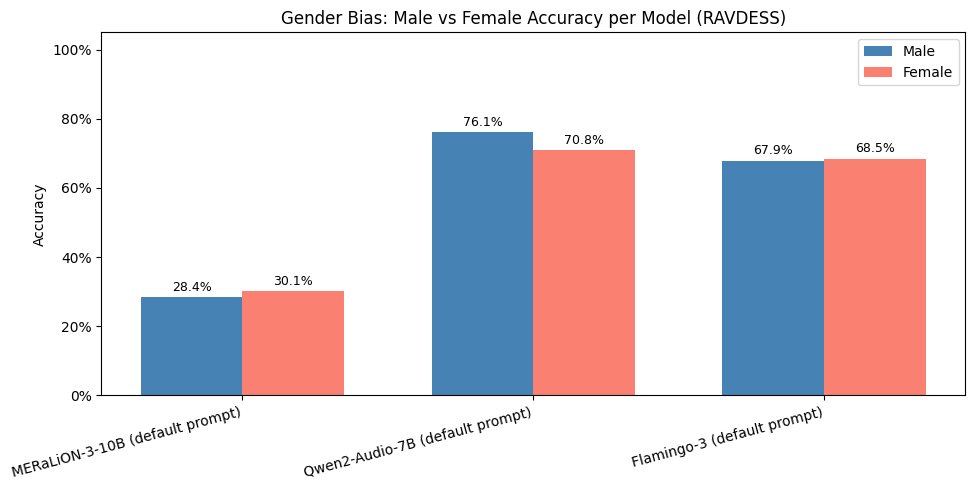

In [96]:
model_labels = list(gender_accs.keys())
male_accs   = [gender_accs[m][0] for m in model_labels]
female_accs = [gender_accs[m][1] for m in model_labels]

x = np.arange(len(model_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_m = ax.bar(x - width/2, male_accs,   width, label='Male',   color='steelblue')
bars_f = ax.bar(x + width/2, female_accs, width, label='Female', color='salmon')

ax.set_ylabel('Accuracy')
ax.set_title('Gender Bias: Male vs Female Accuracy per Model (RAVDESS)')
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

for bar in bars_m:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)
for bar in bars_f:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

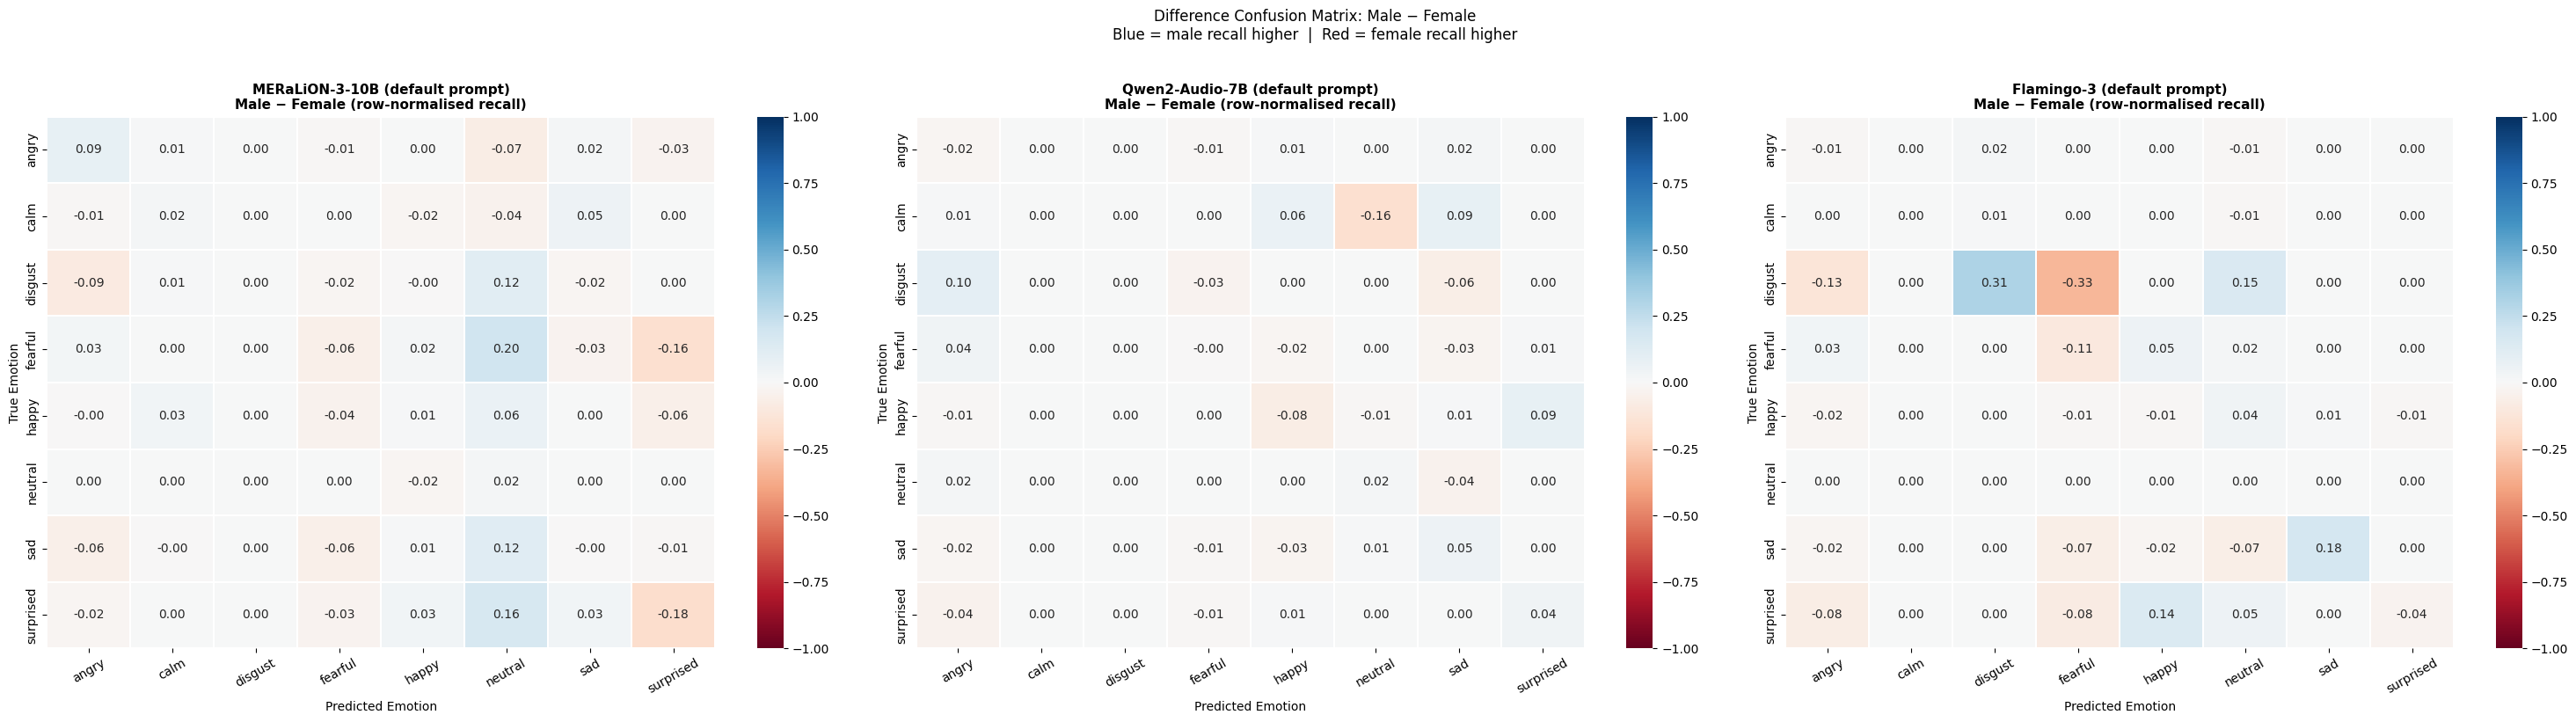

In [97]:
def plot_diff_confusion_matrix(results, ground_truth, model_name, ax):
    y_true_m, y_pred_m = [], []
    y_true_f, y_pred_f = [], []

    for filename, true_label in ground_truth.items():
        pred = normalize(results.get(filename, ""))
        if pred not in VALID_EMOTIONS:
            continue
        gender = get_gender(filename)
        if gender == 'male':
            y_true_m.append(true_label)
            y_pred_m.append(pred)
        elif gender == 'female':
            y_true_f.append(true_label)
            y_pred_f.append(pred)

    cm_m = confusion_matrix(y_true_m, y_pred_m, labels=VALID_EMOTIONS).astype(float)
    cm_f = confusion_matrix(y_true_f, y_pred_f, labels=VALID_EMOTIONS).astype(float)

    # Row-normalize (recall per class), then subtract
    cm_m_norm = cm_m / cm_m.sum(axis=1, keepdims=True).clip(min=1)
    cm_f_norm = cm_f / cm_f.sum(axis=1, keepdims=True).clip(min=1)
    diff = cm_m_norm - cm_f_norm

    sns.heatmap(diff, annot=True, fmt='.2f', cmap='RdBu', center=0,
                vmin=-1, vmax=1,
                xticklabels=VALID_EMOTIONS, yticklabels=VALID_EMOTIONS,
                cbar=True, ax=ax, linewidths=0.3)
    ax.set_title(f"{model_name}\nMale − Female (row-normalised recall)", fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Emotion')
    ax.set_ylabel('True Emotion')
    ax.tick_params(axis='x', rotation=30)

n = len(all_results)
fig, axes = plt.subplots(1, n, figsize=(10 * n, 8))
if n == 1:
    axes = [axes]

for ax, (model_name, results) in zip(axes, all_results.items()):
    plot_diff_confusion_matrix(results, ground_truth, model_name, ax)

plt.suptitle('Difference Confusion Matrix: Male − Female\nBlue = male recall higher  |  Red = female recall higher',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### Zusätzliche Bias-Analysen
Drei weitere Auswertungen, die über den groben M-vs-F-Accuracy-Vergleich hinausgehen:

1. **Compliance-Bias** — Verweigert das Modell bei einem Geschlecht öfter ein parsbares Label?
2. **Bootstrap-CI** — Ist der gemessene Accuracy-Gap statistisch real?
3. **Sprecher-Varianz** — Ist der Gap durch wenige Einzelsprecher getrieben? (Auf RAVDESS mit 24 Schauspielern besonders aussagekräftig.)

In [98]:
# === Bias-Analyse 1: Invalid-Output-Rate je Geschlecht (Compliance-Bias) ===
# Frage: Verweigert das Modell bei einem Geschlecht oeftner ein parsbares Label?
import pandas as pd

invalid_rows = []
for model_name, results in all_results.items():
    n_m = inv_m = n_f = inv_f = 0
    for filename in ground_truth.keys():
        if filename not in results:
            continue
        g = get_gender(filename)
        if g == 'male':
            n_m += 1
            if normalize(results[filename]) not in VALID_EMOTIONS:
                inv_m += 1
        elif g == 'female':
            n_f += 1
            if normalize(results[filename]) not in VALID_EMOTIONS:
                inv_f += 1
    rate_m = inv_m / n_m if n_m else 0
    rate_f = inv_f / n_f if n_f else 0
    invalid_rows.append({
        'Model':       model_name,
        'M total':     n_m,
        'M invalid':   inv_m,
        'M rate':      f'{rate_m:.1%}',
        'F total':     n_f,
        'F invalid':   inv_f,
        'F rate':      f'{rate_f:.1%}',
        'Gap (M-F)':   f'{(rate_m - rate_f)*100:+.1f} pp',
    })

print("Invalid-Output-Rate je Geschlecht (Compliance-Bias)\n")
print(pd.DataFrame(invalid_rows).to_string(index=False))


Invalid-Output-Rate je Geschlecht (Compliance-Bias)

                          Model  M total  M invalid M rate  F total  F invalid F rate Gap (M-F)
MERaLiON-3-10B (default prompt)      720         12   1.7%      720         20   2.8%   -1.1 pp
Qwen2-Audio-7B (default prompt)      720         89  12.4%      720         34   4.7%   +7.6 pp
    Flamingo-3 (default prompt)      720        103  14.3%      720        114  15.8%   -1.5 pp


In [99]:
# === Bias-Analyse 2: Bootstrap-95%-CI auf den Accuracy-Gap ===
# Frage: Ist der Gender-Gap statistisch real oder Sampling-Rauschen?
# 1000 Resamples mit Wiederlegung pro Geschlecht; CI durch Perzentile.
import pandas as pd

N_BOOTSTRAP = 1000
rng = np.random.default_rng(42)

ci_rows = []
for model_name, results in all_results.items():
    correct_m, correct_f = [], []
    for filename, true_label in ground_truth.items():
        pred = normalize(results.get(filename, ""))
        if pred not in VALID_EMOTIONS:
            continue
        g = get_gender(filename)
        if g == 'male':
            correct_m.append(pred == true_label)
        elif g == 'female':
            correct_f.append(pred == true_label)

    arr_m = np.array(correct_m, dtype=bool)
    arr_f = np.array(correct_f, dtype=bool)
    acc_m, acc_f = arr_m.mean(), arr_f.mean()
    gap = acc_f - acc_m

    gaps = np.empty(N_BOOTSTRAP)
    for i in range(N_BOOTSTRAP):
        gaps[i] = rng.choice(arr_f, size=len(arr_f), replace=True).mean() - \
                  rng.choice(arr_m, size=len(arr_m), replace=True).mean()
    ci_low, ci_high = np.percentile(gaps, [2.5, 97.5])
    is_sig = (ci_low > 0) or (ci_high < 0)

    ci_rows.append({
        'Model': model_name,
        'N (M/F)': f'{len(arr_m)}/{len(arr_f)}',
        'Acc M': f'{acc_m:.1%}',
        'Acc F': f'{acc_f:.1%}',
        'Gap (F-M)': f'{gap*100:+.2f} pp',
        '95% CI': f'[{ci_low*100:+.2f}, {ci_high*100:+.2f}] pp',
        'Significant?': 'yes' if is_sig else 'no',
    })

print("Bootstrap 95%-CI auf den Female-Male Accuracy-Gap (n=1000)\n")
print(pd.DataFrame(ci_rows).to_string(index=False))


Bootstrap 95%-CI auf den Female-Male Accuracy-Gap (n=1000)

                          Model N (M/F) Acc M Acc F Gap (F-M)            95% CI Significant?
MERaLiON-3-10B (default prompt) 708/700 28.4% 30.1%  +1.75 pp [-3.06, +7.03] pp           no
Qwen2-Audio-7B (default prompt) 631/686 76.1% 70.8%  -5.22 pp [-9.91, -0.33] pp          yes
    Flamingo-3 (default prompt) 617/606 67.9% 68.5%  +0.57 pp [-4.83, +5.81] pp           no


In [100]:
# === Bias-Analyse 3: Per-Sprecher-Accuracy ===
# Frage: Ist der Gender-Gap durch wenige Sprecher getrieben oder gleichmaessig?
# RAVDESS hat 24 Schauspieler (12 ungerade = male, 12 gerade = female) —
# robusterer Test als auf EmoDB mit nur 5+5 Sprechern.
from collections import defaultdict

print("Per-Sprecher-Accuracy (RAVDESS: 12 M / 12 F)\n")
for model_name, results in all_results.items():
    sp_correct = defaultdict(lambda: [0, 0])  # [correct, total]
    for filename, true_label in ground_truth.items():
        pred = normalize(results.get(filename, ""))
        if pred not in VALID_EMOTIONS:
            continue
        parts = Path(filename).stem.split('-')
        if len(parts) < 7:
            continue
        actor = int(parts[6])
        sp_correct[actor][1] += 1
        if pred == true_label:
            sp_correct[actor][0] += 1

    m_ids = sorted(a for a in sp_correct if a % 2 == 1 and sp_correct[a][1] > 0)
    f_ids = sorted(a for a in sp_correct if a % 2 == 0 and sp_correct[a][1] > 0)
    m_accs = [sp_correct[a][0] / sp_correct[a][1] for a in m_ids]
    f_accs = [sp_correct[a][0] / sp_correct[a][1] for a in f_ids]

    print(f"--- {model_name} ---")
    if m_accs and f_accs:
        m_range = max(m_accs) - min(m_accs)
        f_range = max(f_accs) - min(f_accs)
        gap_mean = np.mean(f_accs) - np.mean(m_accs)
        print(f"  Male   ({len(m_accs)} actors): mean={np.mean(m_accs):.1%}  std={np.std(m_accs):.1%}  range=[{min(m_accs):.1%}, {max(m_accs):.1%}]")
        print(f"  Female ({len(f_accs)} actors): mean={np.mean(f_accs):.1%}  std={np.std(f_accs):.1%}  range=[{min(f_accs):.1%}, {max(f_accs):.1%}]")
        print(f"  Sprecher-gemittelter Gap (F-M): {gap_mean*100:+.1f} pp")
        if abs(gap_mean) < max(m_range, f_range) / 2:
            print(f"  HINWEIS: Gap ist klein gegenueber Sprecher-Varianz - moeglicherweise von Einzelsprechern getrieben.")
    print()


Per-Sprecher-Accuracy (RAVDESS: 12 M / 12 F)

--- MERaLiON-3-10B (default prompt) ---
  Male   (12 actors): mean=28.4%  std=3.9%  range=[21.7%, 36.2%]
  Female (12 actors): mean=30.2%  std=4.9%  range=[25.4%, 43.6%]
  Sprecher-gemittelter Gap (F-M): +1.8 pp
  HINWEIS: Gap ist klein gegenueber Sprecher-Varianz - moeglicherweise von Einzelsprechern getrieben.

--- Qwen2-Audio-7B (default prompt) ---
  Male   (12 actors): mean=76.1%  std=4.4%  range=[69.1%, 84.3%]
  Female (12 actors): mean=70.9%  std=4.8%  range=[61.7%, 77.2%]
  Sprecher-gemittelter Gap (F-M): -5.2 pp
  HINWEIS: Gap ist klein gegenueber Sprecher-Varianz - moeglicherweise von Einzelsprechern getrieben.

--- Flamingo-3 (default prompt) ---
  Male   (12 actors): mean=68.0%  std=6.8%  range=[51.9%, 76.5%]
  Female (12 actors): mean=68.5%  std=7.2%  range=[55.6%, 82.0%]
  Sprecher-gemittelter Gap (F-M): +0.6 pp
  HINWEIS: Gap ist klein gegenueber Sprecher-Varianz - moeglicherweise von Einzelsprechern getrieben.

